Solving a variant of problem 6.3, Gray, Costanzo, and Plesha (Gray, G.L., Costanzo, F., and Plesha, M.E., *Engineering Mechanics: Dynamics*, McGraw Hill, New York, 2010.), where kinetics are included ($I_1, I_2, I_3$) and a moment $M$ is applied to the rightmost gear.

The problem statement is ``A Moment $M$ is applied to the rightmost gear (gear 3). Find the acceleration of the gear as a resulting moment presuming inertias $I_1, I_2, I_3$.''

## Governing equations

Before working through the solution step by step, here are all the equations to be solved, gathered in one place. Each expression is set equal to zero (SymPy's convention for an equation, as noted below).

Kinetic equations (from the free body diagrams):

$$F_{DC} r_{D} - I_{3} \frac{d^{2}}{d t^{2}} \theta_{3}{\left(t \right)} = 0 \qquad (E_A)$$

$$F_{AB} r_{B} - F_{DC} r_{C} - I_{2} \frac{d^{2}}{d t^{2}} \theta_{2}{\left(t \right)} = 0 \qquad (E_B)$$

$$- F_{AB} r_{A} - I_{1} \frac{d^{2}}{d t^{2}} \theta_{1}{\left(t \right)} + M = 0 \qquad (E_C)$$

Kinematic constraints (relating the angular accelerations through the gear radii):

$$- r_{C} \frac{d^{2}}{d t^{2}} \theta_{2}{\left(t \right)} + r_{D} \frac{d^{2}}{d t^{2}} \theta_{3}{\left(t \right)} = 0 \qquad (E_1)$$

$$- r_{A} \frac{d^{2}}{d t^{2}} \theta_{1}{\left(t \right)} + r_{B} \frac{d^{2}}{d t^{2}} \theta_{2}{\left(t \right)} = 0 \qquad (E_2)$$

The goal is to solve this system for $\ddot{\theta}_3$ in terms of $M$ and the given inertias/radii.

In [1]:
#<img src="Gears.png">

In [2]:
# import symbolic capability to Python
from sympy import *

In [3]:
# print things all pretty
from sympy.abc import *
init_printing()

In [4]:
# Need to define variables as symbolic for sympy to use them. 
r_A, r_B, r_C, r_D, F_AB, F_DC, M= symbols("r_A r_B r_C r_D F_AB F_DC M", real = True)

In [5]:
I_1, I_2, I_3 = symbols("I_1 I_2 I_3", real = True)

In [6]:
# theta_1, theta_2, theta_3 must be functions of t (not bare symbols) so that
# theta_i(t) and its time-derivatives below are meaningful, and so diff(...)
# produces an actual (unevaluated) Derivative rather than raising a TypeError.
theta_1, theta_2, theta_3 = symbols("theta_1 theta_2 theta_3", cls=Function)

The Free Body Diagrams, and kinematic relationships. 
<img src="images/Quiz2.png">

Defining equations. In SymPy, and equation is an expression that is equal to zero. All terms must be brought to the same side in defining it. 

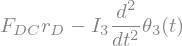

In [7]:
EA = F_DC *r_D  - I_3 * diff(theta_3(t),t,t)
EA

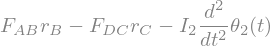

In [8]:
EB = r_B* F_AB - r_C* F_DC - I_2 * diff(theta_2(t),t,t)
EB

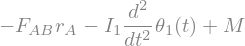

In [9]:
EC = r_A *(-F_AB) + M - I_1 * diff(theta_1(t),t,t)
EC

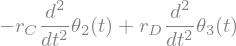

In [10]:
E1 = diff(theta_3(t),t,t)* r_D - diff(theta_2(t),t,t) *r_C
E1

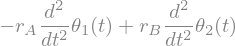

In [11]:
E2 = r_B * diff(theta_2(t),t,t) - diff(theta_1(t),t,t) *r_A
E2

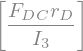

In [12]:
solve(EA,diff(theta_3(t),t,t))

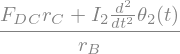

In [13]:
solve(EB,F_AB)[0]

I'm going to do substitutions in stages, eliminating one variable at a time for clarity.

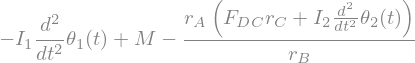

In [14]:
step1 = EC.subs(F_AB, solve(EB,F_AB)[0])
step1

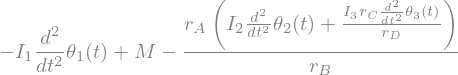

In [15]:
step2 = step1.subs(F_DC,solve(EA,F_DC)[0])
step2

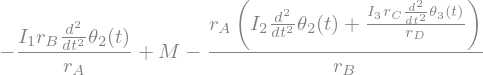

In [16]:
step3 = step2.subs(diff(theta_1(t),t,t),solve(E2,diff(theta_1(t),t,t))[0])
step3

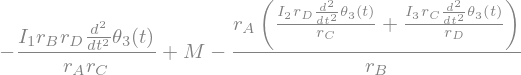

In [17]:
step4 = step3.subs(diff(theta_2(t),t,t),solve(E1,diff(theta_2(t),t,t))[0])
step4

Finally, the acceleration of the right most gear as a function of the input moment

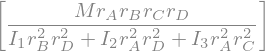

In [18]:
solve(step4,diff(theta_3(t),t,t))